C:\Users\96498\AppData\Local\Temp\ipykernel_20052\2377632281.py:51: UserWarning: Glyph 23567 (\N{CJK UNIFIED IDEOGRAPH-5C0F}) missing from current font.
  canvas.draw()
C:\Users\96498\AppData\Local\Temp\ipykernel_20052\2377632281.py:51: UserWarning: Glyph 26102 (\N{CJK UNIFIED IDEOGRAPH-65F6}) missing from current font.
  canvas.draw()
C:\Users\96498\AppData\Local\Temp\ipykernel_20052\2377632281.py:51: UserWarning: Glyph 30005 (\N{CJK UNIFIED IDEOGRAPH-7535}) missing from current font.
  canvas.draw()
C:\Users\96498\AppData\Local\Temp\ipykernel_20052\2377632281.py:51: UserWarning: Glyph 37327 (\N{CJK UNIFIED IDEOGRAPH-91CF}) missing from current font.
  canvas.draw()
C:\Users\96498\AppData\Local\Temp\ipykernel_20052\2377632281.py:51: UserWarning: Glyph 20013 (\N{CJK UNIFIED IDEOGRAPH-4E2D}) missing from current font.
  canvas.draw()
C:\Users\96498\AppData\Local\Temp\ipykernel_20052\2377632281.py:51: UserWarning: Glyph 38271 (\N{CJK UNIFIED IDEOGRAPH-957F}) missing from current font.
  

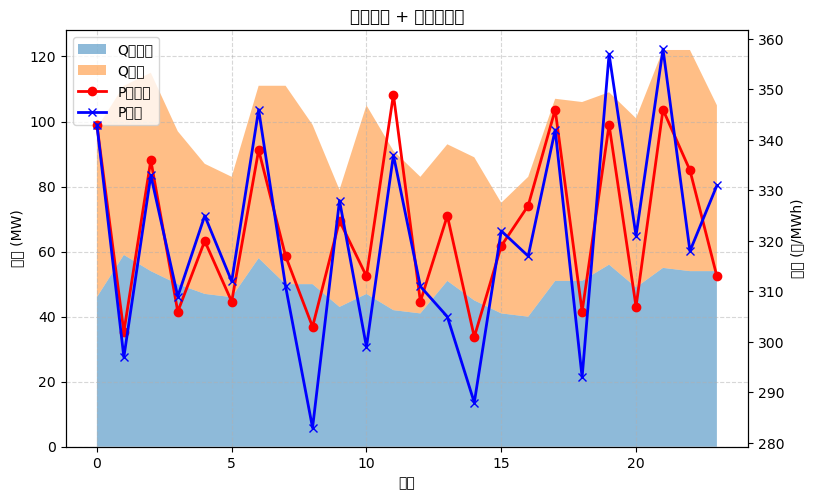

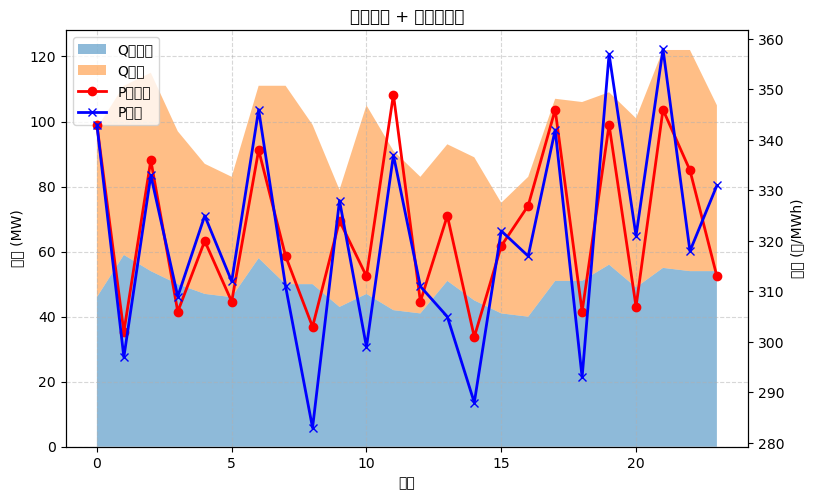

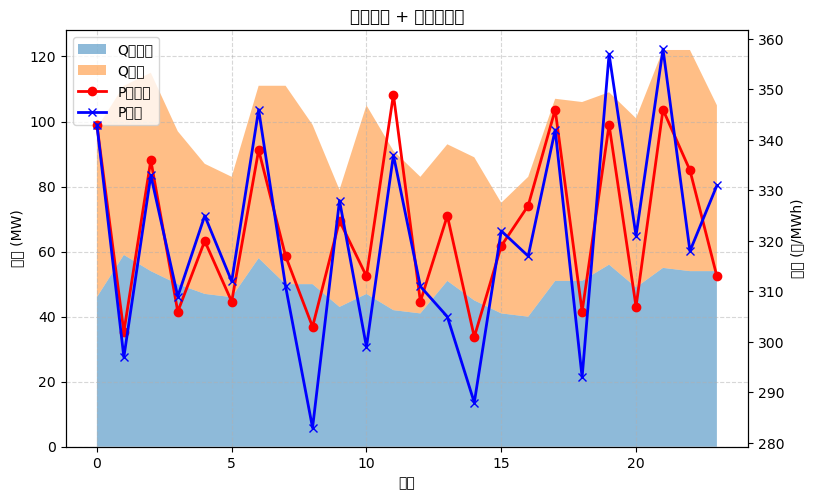

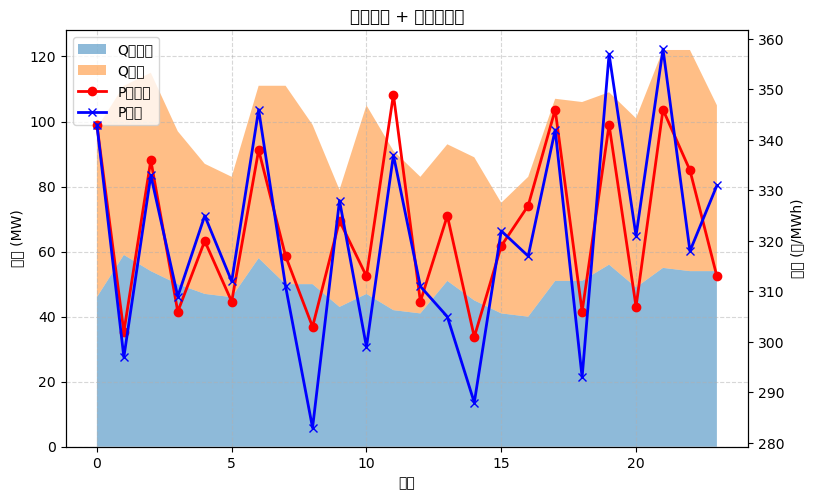

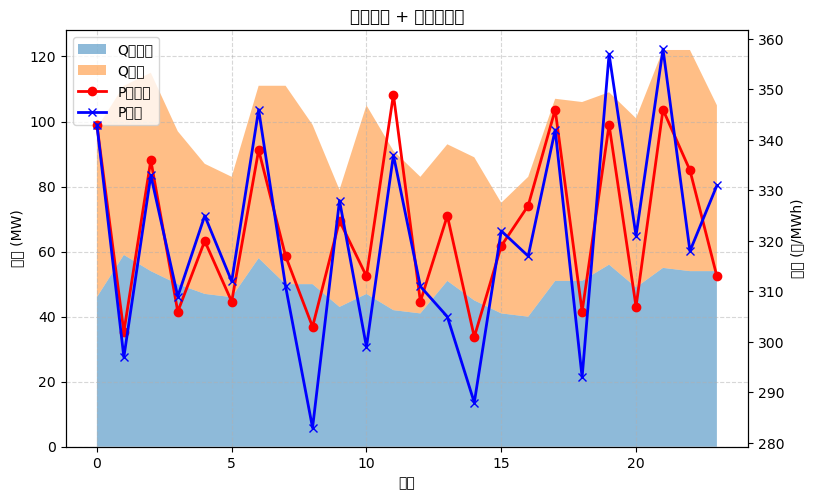

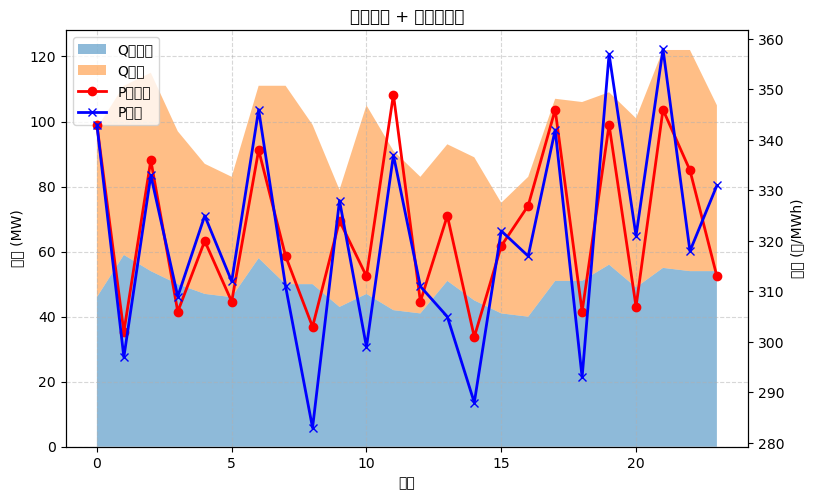

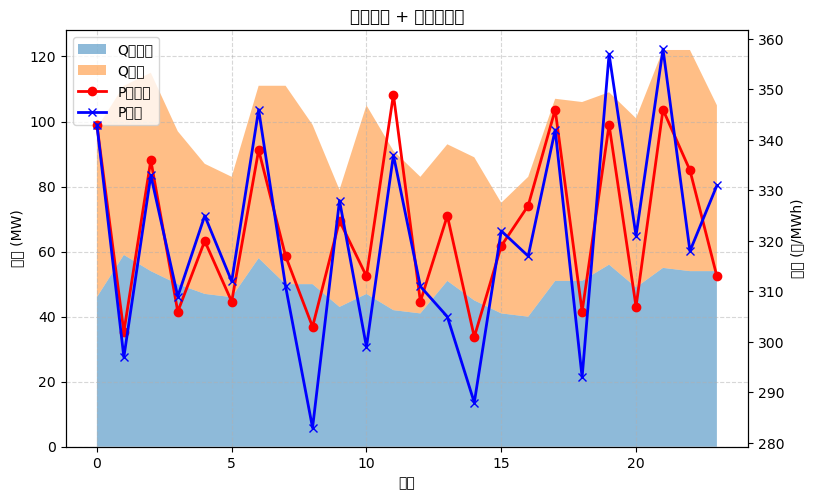

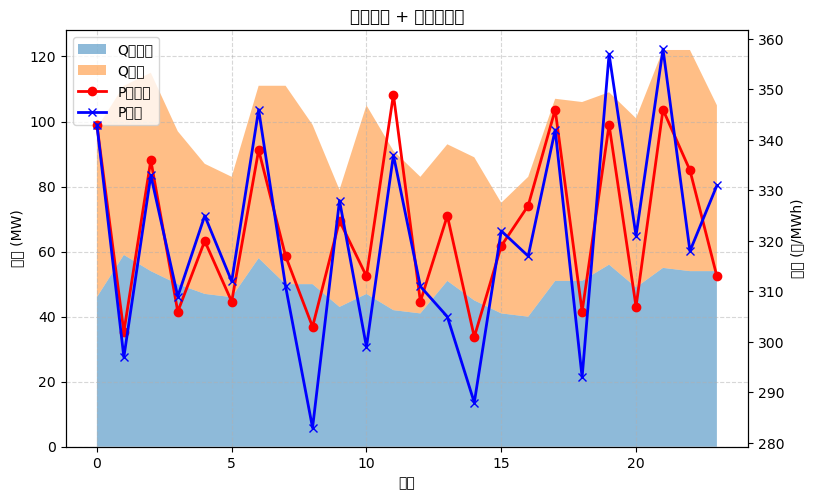

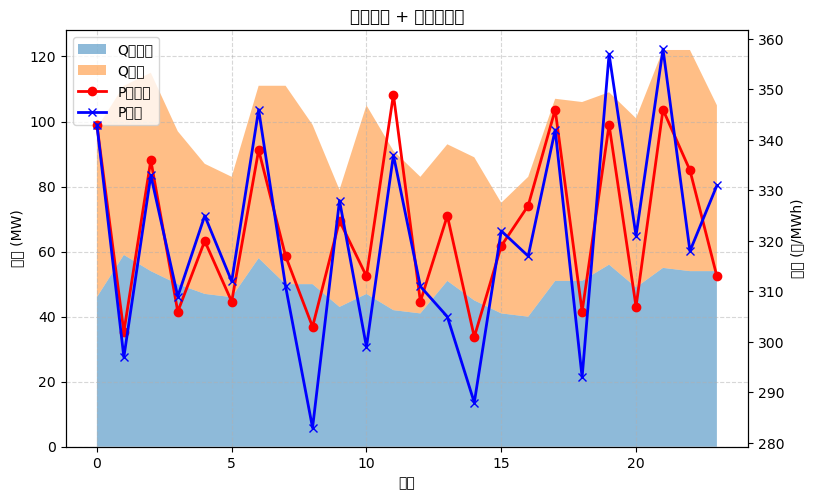

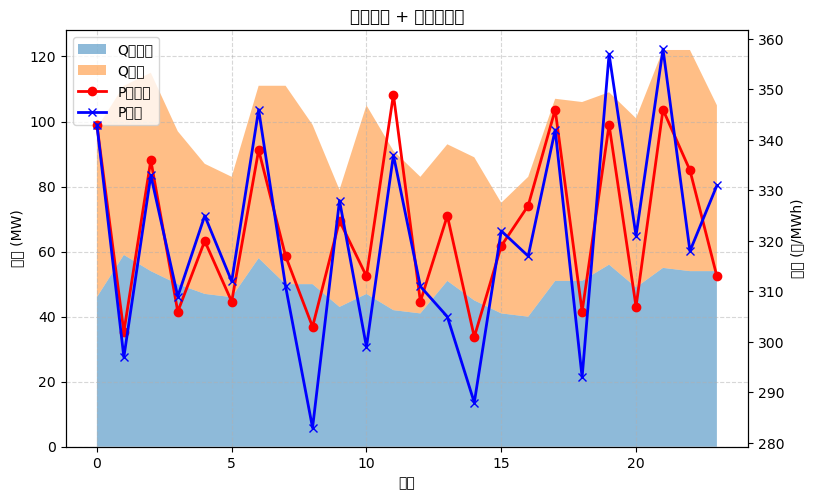

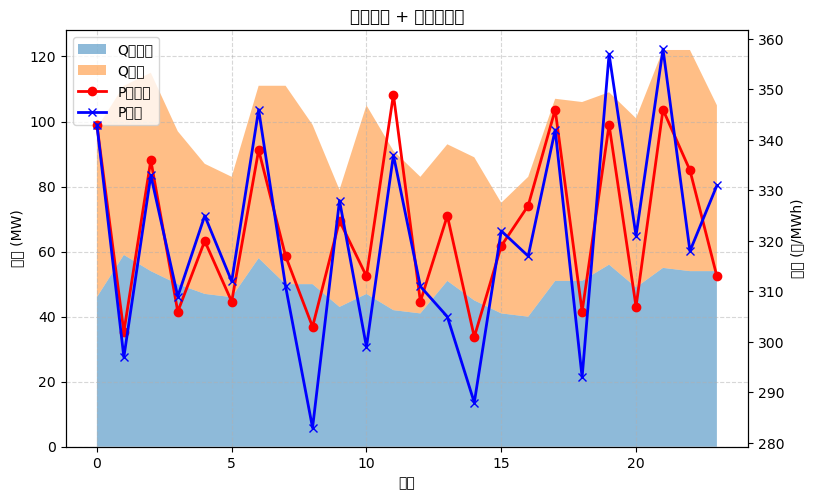

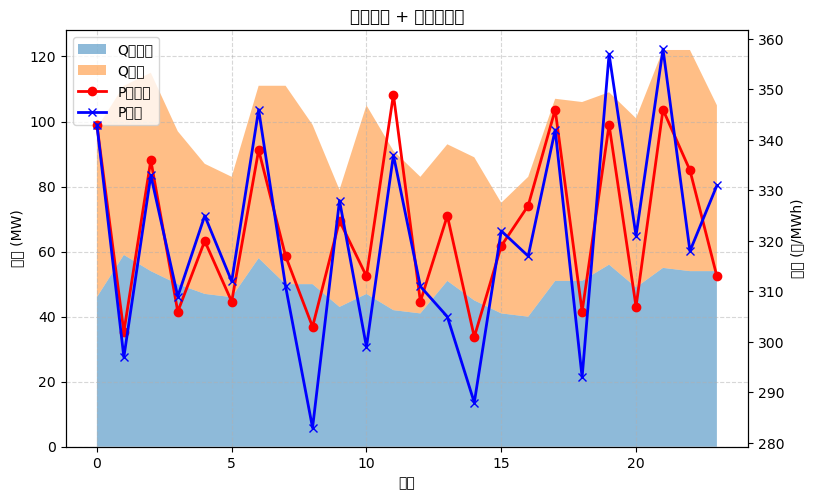

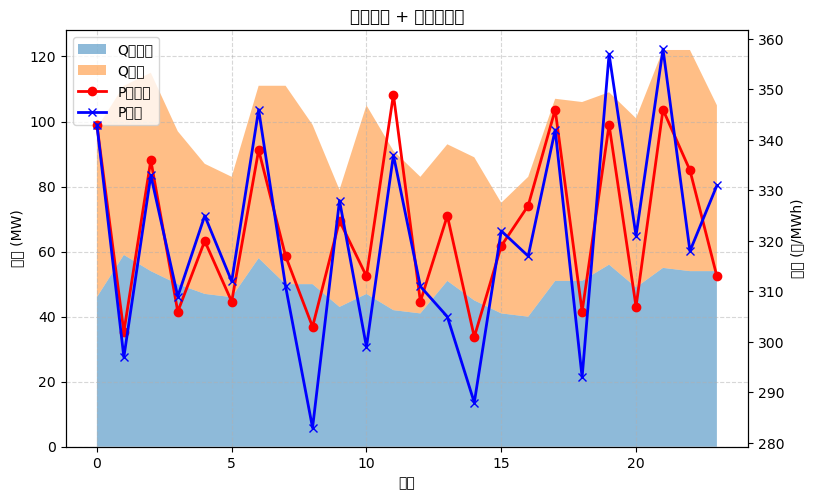

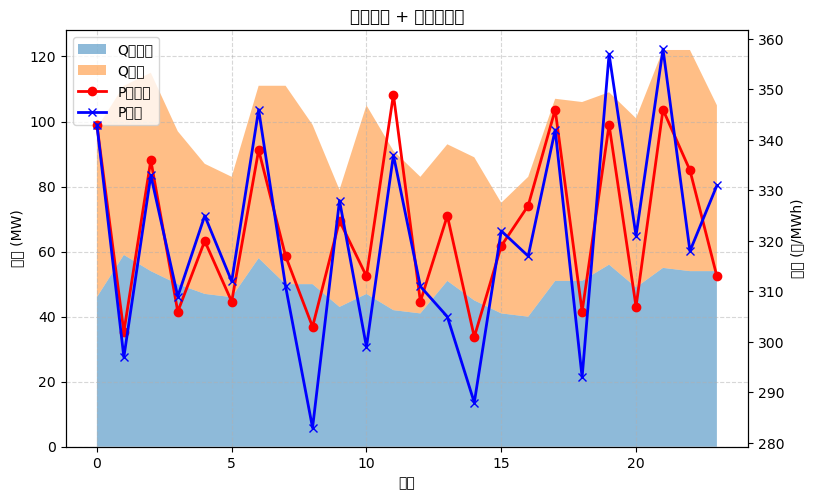

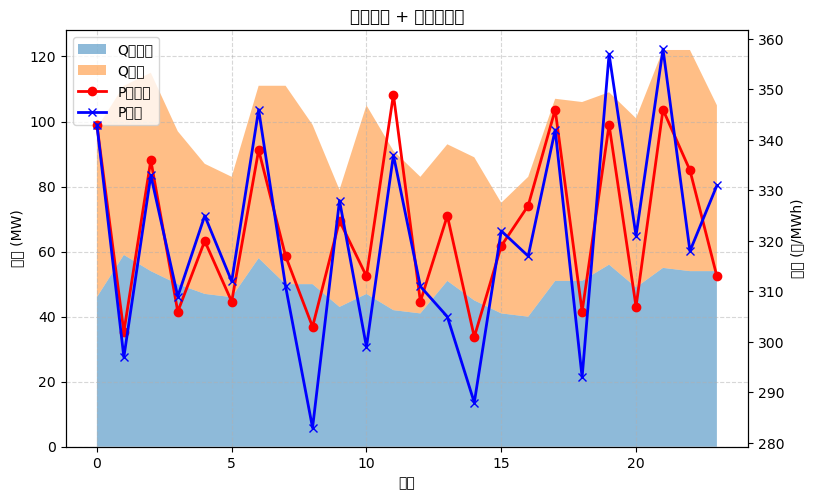

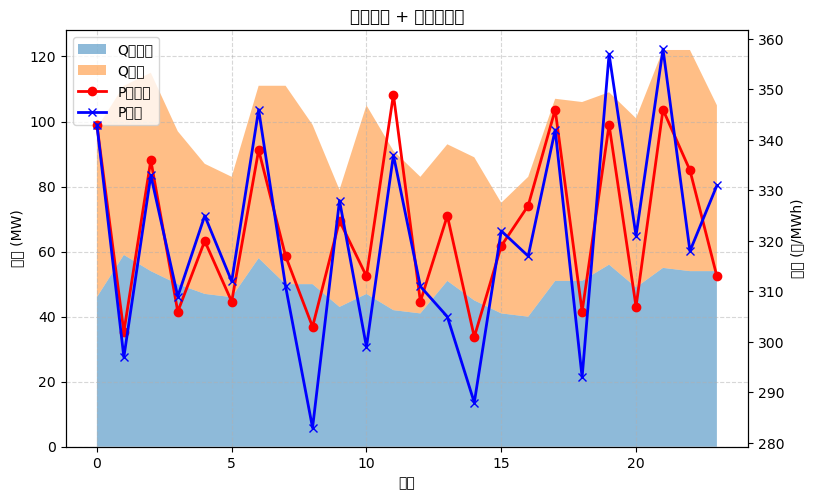

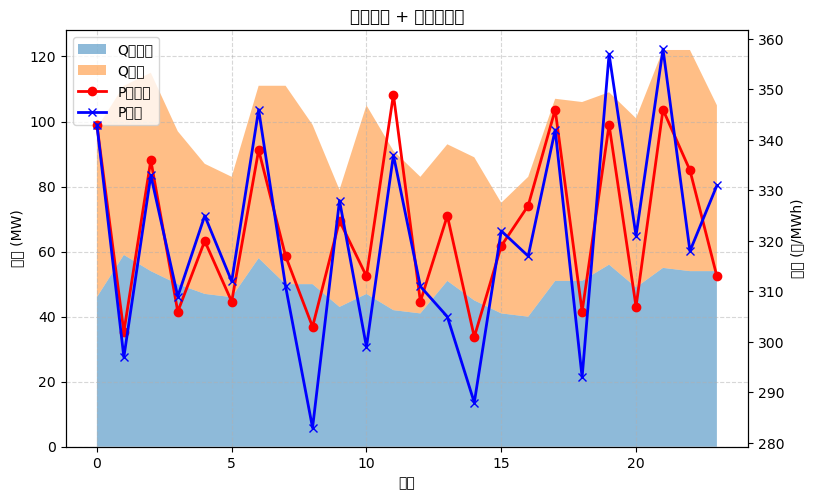

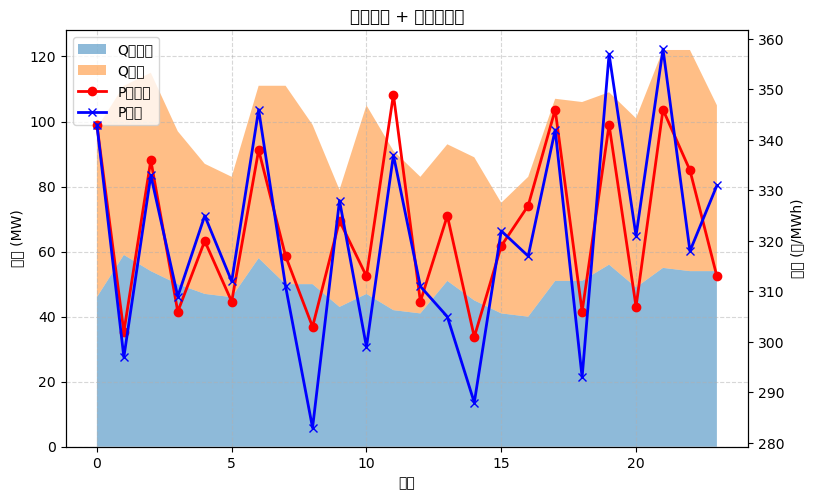

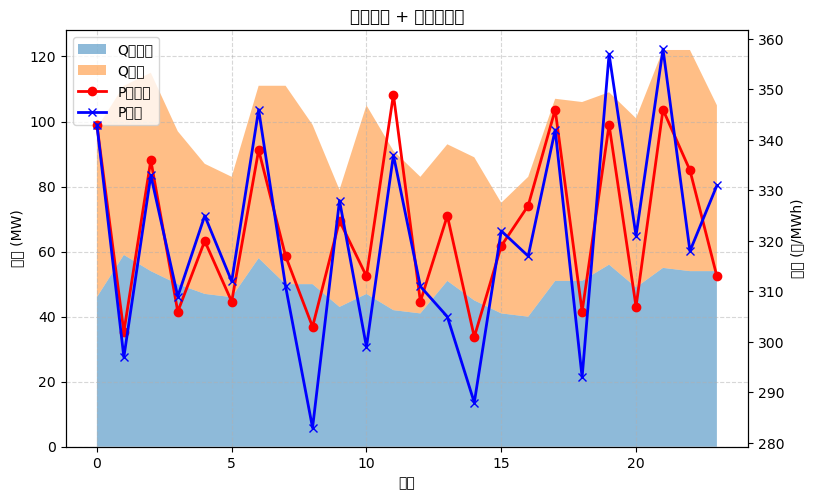

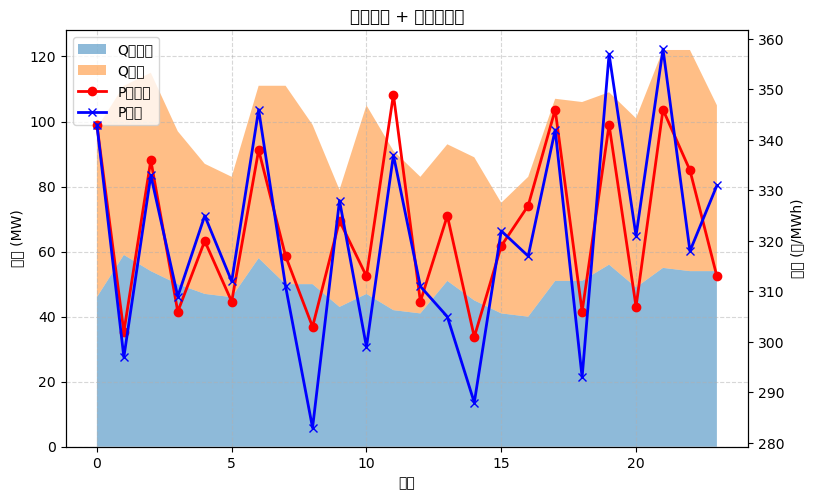

In [2]:
import tkinter as tk
from tkinter import ttk
from tkinter import messagebox
import matplotlib.pyplot as plt
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg
import pandas as pd
import numpy as np

# ==== 模拟数据 + 画图逻辑 ====
def simulate_and_plot():
    np.random.seed(42)
    hours = list(range(24))
    Q_mid = np.random.randint(40, 60, size=24)
    P_mid = np.random.randint(300, 350, size=24)
    Q_day = Q_mid + np.random.randint(-10, 15, size=24)
    P_day = P_mid + np.random.randint(-20, 20, size=24)
    df = pd.DataFrame([Q_mid, P_mid, Q_day, P_day],
                      index=["Q中长期", "P中长期", "Q日前", "P日前"],
                      columns=hours)
    return df

def plot_qp(df, frame):
    hours = df.columns.astype(int)
    q_mid = df.loc["Q中长期"].values
    p_mid = df.loc["P中长期"].values
    q_day = df.loc["Q日前"].values
    p_day = df.loc["P日前"].values

    fig, ax1 = plt.subplots(figsize=(8,5))

    ax1.stackplot(hours, q_mid, q_day, labels=['Q中长期', 'Q日前'], alpha=0.5)
    ax1.set_xlabel("小时")
    ax1.set_ylabel("电量 (MW)")
    ax1.grid(True, linestyle='--', alpha=0.5)

    ax2 = ax1.twinx()
    ax2.plot(hours, p_mid, color='red', label="P中长期", linewidth=2, marker='o')
    ax2.plot(hours, p_day, color='blue', label="P日前", linewidth=2, marker='x')
    ax2.set_ylabel("价格 (元/MWh)")

    lines, labels = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines + lines2, labels + labels2, loc="upper left")

    plt.title("电量堆叠 + 电价折线图")

    # 把图嵌入到Tkinter窗口中
    for widget in frame.winfo_children():
        widget.destroy()
    canvas = FigureCanvasTkAgg(fig, master=frame)
    canvas.draw()
    canvas.get_tk_widget().pack(fill=tk.BOTH, expand=True)

# ==== GUI部分 ====
root = tk.Tk()
root.title("电量电价分析可视化Demo")
root.geometry("900x600")

# 上方按钮区
control_frame = ttk.Frame(root)
control_frame.pack(side=tk.TOP, fill=tk.X, padx=10, pady=5)

btn_run = ttk.Button(control_frame, text="生成模拟图", command=lambda: plot_qp(simulate_and_plot(), plot_frame))
btn_run.pack(side=tk.LEFT, padx=10)

# 图表显示区
plot_frame = ttk.Frame(root)
plot_frame.pack(fill=tk.BOTH, expand=True, padx=10, pady=10)

root.mainloop()
